<a href="https://colab.research.google.com/github/halandamulakkayala-tech/SmartMeal-AI/blob/main/SmartMeal_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files

# Upload file
uploaded = files.upload()

# Read dataset
df = pd.read_csv('messy_restaurant_food_waste_dataset.csv')

# Remove extra spaces
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# Replace blank values with NaN
df.replace('', pd.NA, inplace=True)
df.replace(' ', pd.NA, inplace=True)

# Replace invalid values
df.replace('unknown', pd.NA, inplace=True)
df.replace('UNKNOWN', pd.NA, inplace=True)

# Standardize text format
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.title()

# Convert numeric columns and fill missing values
numeric_columns = ['Quantity_Cooked', 'Quantity_Sold']

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].mean())

# Fill missing values in text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('Unknown')

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

# Save cleaned dataset
df.to_csv('cleaned_restaurant_food_waste_dataset.csv', index=False)

# Download cleaned dataset
files.download('cleaned_restaurant_food_waste_dataset.csv')

Saving messy_restaurant_food_waste_dataset.csv to messy_restaurant_food_waste_dataset (1).csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

         Date   Restaurant    Dish  Quantity_Cooked  Quantity_Sold  \
0  01-08-2025   Green Leaf   Pizza        44.000000           31.0   
1         Nan    Spice Hub   Pizza       105.000000           82.0   
2  01-08-2025  Urban Bites  Burger        47.000000           46.0   
3  01-08-2025   Food Plaza   Pizza       108.000000           85.0   
4  01-08-2025  Tasty Treat  Burger        67.894737           31.0   

   Quantity_Leftover  Quantity_Donated Weather  Quantity_Cooked.1  \
0                 13                 8   Rainy                 44   
1                 23                 9  Cloudy                105   
2                  1                 0  Cloudy                 47   
3                 23                 4   Rainy                108   
4                 18                15   Rainy                 49   

   Quantity_Sold.1  ...  Quantity_Cooked.6  Quantity_Sold.6  \
0               31  ...                 44               31   
1               82  ...               

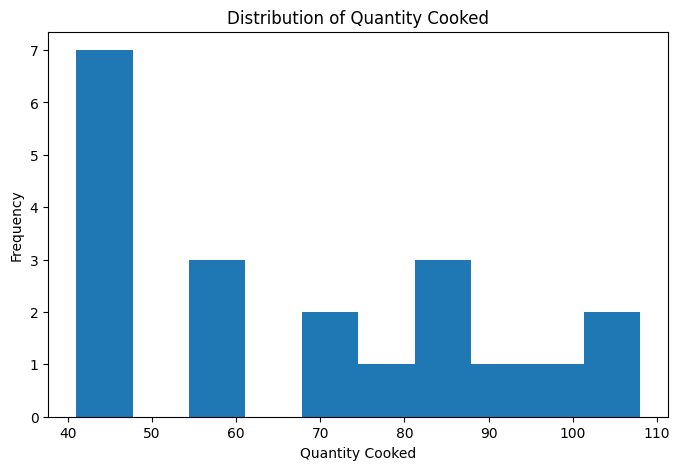

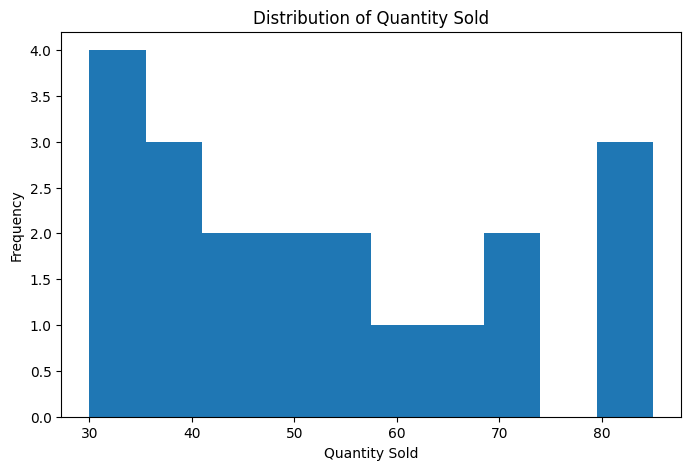


Correlation Matrix:
                     Quantity_Cooked  Quantity_Sold  Quantity_Leftover  \
Quantity_Cooked             1.000000       0.860536           0.655038   
Quantity_Sold               0.860536       1.000000           0.218802   
Quantity_Leftover           0.655038       0.218802           1.000000   
Quantity_Donated            0.346471      -0.047470           0.685951   
Quantity_Cooked.1           0.982674       0.896923           0.625053   
Quantity_Sold.1             0.881572       0.997018           0.264707   
Quantity_Leftover.1         0.655038       0.218802           1.000000   
Quantity_Donated.1          0.346471      -0.047470           0.685951   
Quantity_Cooked.2           0.982674       0.896923           0.625053   
Quantity_Sold.2             0.881572       0.997018           0.264707   
Quantity_Leftover.2         0.655038       0.218802           1.000000   
Quantity_Donated.2          0.346471      -0.047470           0.685951   
Quantity_Cooked.3

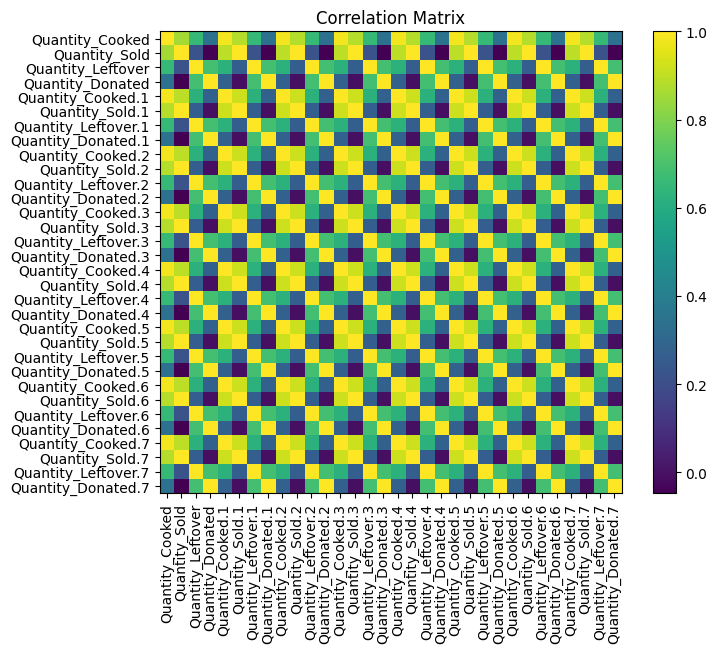

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv('cleaned_restaurant_food_waste_dataset.csv')

# Display first 5 rows
print(df.head())

# Dataset information
print("\nDataset Information:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate values
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Distribution of Quantity Cooked
plt.figure(figsize=(8,5))
plt.hist(df['Quantity_Cooked'])
plt.title('Distribution of Quantity Cooked')
plt.xlabel('Quantity Cooked')
plt.ylabel('Frequency')
plt.show()

# Distribution of Quantity Sold
plt.figure(figsize=(8,5))
plt.hist(df['Quantity_Sold'])
plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Frequency')
plt.show()

# Correlation between numerical columns
correlation = df.select_dtypes(include=['int64','float64']).corr()
print("\nCorrelation Matrix:")
print(correlation)

# Visualize correlation matrix
plt.figure(figsize=(8,6))
plt.imshow(correlation)
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Correlation Matrix')
plt.show()

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load cleaned dataset
df = pd.read_csv('cleaned_restaurant_food_waste_dataset.csv')

# Create target column if not already present
if 'Food_Waste' not in df.columns:
    df['Food_Waste'] = df['Quantity_Cooked'] - df['Quantity_Sold']

# Encode categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Separate features and target
X = df.drop('Food_Waste', axis=1)
y = df['Food_Waste']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (16, 43)
Testing Features Shape: (4, 43)
Training Target Shape: (16,)
Testing Target Shape: (4,)


In [4]:
from sklearn.ensemble import RandomForestRegressor

# Create model
model = RandomForestRegressor(random_state=42)

# Train model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 1.0898684210526342
Mean Squared Error: 2.80191018005542
Root Mean Squared Error: 1.6738907312173694
R2 Score: 0.8950103913796564


In [6]:
prediction = model.predict([X_test.iloc[0]])
print("Predicted Food Waste:", prediction[0])

Predicted Food Waste: 12.838947368421053


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
